# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/taqadussana/ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Which content pages, out of thousands, should a content editor review
first for possible refresh?

**Decision supported:** a content editor or SEO reviewer with limited time needs a prioritized
shortlist rather than reviewing pages at random or chronologically. This is the Refresh /
Content Opportunity Scoring lane.

**Unit of analysis:** one content page (content_id).

**Cost of a wrong call:** flagging a healthy page wastes limited review time; missing a
genuinely declining page lets it keep losing visibility unnoticed.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*
**Source:** data/raw/content_refresh_anonymized.csv — the FlyRank ML Internship starter
dataset. 30,000 pseudonymized content pages across 32 clients, trailing-90-day metrics.

**Time window:** the dataset's snapshot window (trailing 90 days per page), plus a
data-contract verification pass (Week 3 / ML-04) against a mid-panel month (2026-03) of the
warehouse release, confirming 9,841,378 rows spanning 2026-03-01 to 2026-03-31, with only
~4.2% of rows having GA4 data available.

**Excluded, with why:** raw queries, URLs, and titles — even pseudonymized, these risk
exposing real client information. FlyRank's own product decision flags (health_score,
priority_score, action_type) were also excluded — using them as features would mean learning
FlyRank's existing rule rather than discovering an independent signal.

In [14]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/taqadussana/ML/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

print("Total pages:", df.shape[0])
print("Unique clients:", df["client_id"].nunique())
print("Share trending down:", round(df["is_declining_label"].mean(), 3))
df.head()

Total pages: 30000
Unique clients: 32
Share trending down: 0.542


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,is_declining_label
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4,1
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7,1
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9,1
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8,0
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7,1


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*
**Label:** is_declining_label = trend_direction == "down" — a current-window proxy, not a
validated future outcome.

**Baseline:** a transparent rule combining staleness (90-180 days since update) and visibility
(90-day impressions, log-scaled), 50/50 weighted, with a reason code per page.

**Model:** Random Forest Classifier (200 trees, max depth 6, balanced class weights) on 8
observable features: avg_position, impressions_90d, sessions_90d, content_age_days,
days_since_last_update, ctr, engagement_rate, word_count.

**Validation design:** client-grouped split (GroupShuffleSplit, 75/25) — entire clients held
out for testing, since pages from the same client can share hidden characteristics that a
random split would let the model memorize.

**Leakage audit:** confirmed no label-derived columns or product flags in the feature set. A
deliberate leak test (adding trend_pct) pushed Precision@K to a suspicious 1.000 — confirming
the evaluation harness correctly detects leakage.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, ShuffleSplit

def assign_reason(row):
    if 90 <= row["days_since_last_update"] <= 180 and row["impressions_90d"] >= 500:
        return "aging_visible_page"
    elif row["impressions_90d"] >= 500:
        return "high_visibility_monitor"
    else:
        return "low_signal"
df["reason_code"] = df.apply(assign_reason, axis=1)

window_center = 135
df["aging_score"] = 1 - (abs(df["days_since_last_update"] - window_center) / df["days_since_last_update"].max()).clip(0, 1)
df["visibility_score"] = np.log1p(df["impressions_90d"]) / np.log1p(df["impressions_90d"].max())
df["baseline_action_score"] = 0.5 * df["aging_score"] + 0.5 * df["visibility_score"]

features = ["avg_position", "impressions_90d", "sessions_90d", "content_age_days",
            "days_since_last_update", "ctr", "engagement_rate", "word_count"]
features = [f for f in features if f in df.columns]

X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]
groups = df["client_id"]

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42)
rf.fit(X.iloc[train_idx], y.iloc[train_idx])
rf_scores = rf.predict_proba(X.iloc[test_idx])[:, 1]
baseline_test = df.iloc[test_idx]["baseline_action_score"].values
y_test = y.iloc[test_idx].values

print("Model trained. Test set size:", len(test_idx))

Model trained. Test set size: 7115


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [15]:
print("Model vs Baseline — same client-grouped test split, same metric\n")
print(f"{'K':<6}{'Baseline':<12}{'Random Forest':<15}")
for k in (20, 50):
    b = precision_at_k(baseline_test, y_test, k)
    m = precision_at_k(rf_scores, y_test, k)
    print(f"{k:<6}{b:<12.3f}{m:<15.3f}")

random_split = ShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
r_train_idx, r_test_idx = next(random_split.split(X, y))
rf_r = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42)
rf_r.fit(X.iloc[r_train_idx], y.iloc[r_train_idx])
rf_r_scores = rf_r.predict_proba(X.iloc[r_test_idx])[:, 1]
y_r_test = y.iloc[r_test_idx].values

print("\nRandom split vs grouped split (memorization check)\n")
print(f"{'K':<6}{'Random split':<16}{'Grouped split':<16}")
for k in (20, 50):
    rand_p = precision_at_k(rf_r_scores, y_r_test, k)
    group_p = precision_at_k(rf_scores, y_test, k)
    print(f"{k:<6}{rand_p:<16.3f}{group_p:<16.3f}")

Model vs Baseline — same client-grouped test split, same metric

K     Baseline    Random Forest  
20    0.200       0.550          
50    0.320       0.580          

Random split vs grouped split (memorization check)

K     Random split    Grouped split   
20    0.950           0.550           
50    0.940           0.580           


## 5. Limitations

*What this work cannot claim.*

This work is observational and decision-support only. It does not claim to predict Google's
ranking algorithm, prove that refreshing a page causes recovery, or guarantee outcomes for any
individual page. All results come from one train/test split on one month's worth of starter
data across 32 clients — not the full multi-year warehouse. Roughly 42-45% of top-ranked pages
will not actually need review (Precision@50 = 0.580), so this is a prioritization aid, never a
certainty engine. The label itself (is_declining_label) is a current-window proxy, not a
validated future outcome.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [16]:
df["model_score"] = rf.predict_proba(X)[:, 1]

def assign_final_reason(row):
    if row["model_score"] >= 0.65 and row["days_since_last_update"] >= 90:
        return "model_decline_risk_stale"
    elif row["model_score"] >= 0.65:
        return "model_decline_risk"
    elif row["impressions_90d"] >= 500 and row["avg_position"] > 10:
        return "visible_but_underranked"
    elif row["impressions_90d"] >= 500 and row["ctr"] < 0.5:
        return "low_ctr_visible_page"
    else:
        return "monitor_only"

df["final_reason_code"] = df.apply(assign_final_reason, axis=1)
action_map = {
    "model_decline_risk_stale": "refresh_content",
    "model_decline_risk": "review_for_refresh",
    "visible_but_underranked": "review_snippet_and_relevance",
    "low_ctr_visible_page": "review_title_and_meta",
    "monitor_only": "no_action",
}
df["final_action"] = df["final_reason_code"].map(action_map)

ranked = df.sort_values("model_score", ascending=False).reset_index(drop=True)
print("Action distribution across all 30,000 pages:\n")
print(ranked["final_action"].value_counts())
print("\nTop 10 highest-priority pages:")
print(ranked[["content_id", "model_score", "final_reason_code", "final_action"]].head(10).to_string(index=False))

Action distribution across all 30,000 pages:

final_action
no_action                       11362
review_snippet_and_relevance     5851
review_for_refresh               5332
review_title_and_meta            4502
refresh_content                  2953
Name: count, dtype: int64

Top 10 highest-priority pages:
          content_id  model_score        final_reason_code    final_action
content_8dba22b835f8     0.765406 model_decline_risk_stale refresh_content
content_fac9e8c13f4c     0.765152 model_decline_risk_stale refresh_content
content_b5286cb71075     0.764843 model_decline_risk_stale refresh_content
content_dc9b1bdd6fd2     0.764758 model_decline_risk_stale refresh_content
content_0361d8df96e6     0.764626 model_decline_risk_stale refresh_content
content_956fa666a622     0.764589 model_decline_risk_stale refresh_content
content_5cda32af644c     0.764442 model_decline_risk_stale refresh_content
content_9428850c5661     0.764322 model_decline_risk_stale refresh_content
content_f92cc1c6fb

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Saved metrics JSON: {'model': 'RandomForestClassifier', 'validation_split': 'client-grouped (GroupShuffleSplit)', 'precision_at_20': np.float64(0.55), 'precision_at_50': np.float64(0.58), 'baseline_precision_at_20': np.float64(0.2), 'baseline_precision_at_50': np.float64(0.32), 'action_distribution': {'no_action': 11362, 'review_snippet_and_relevance': 5851, 'review_for_refresh': 5332, 'review_title_and_meta': 4502, 'refresh_content': 2953}, 'total_pages_scored': 30000}


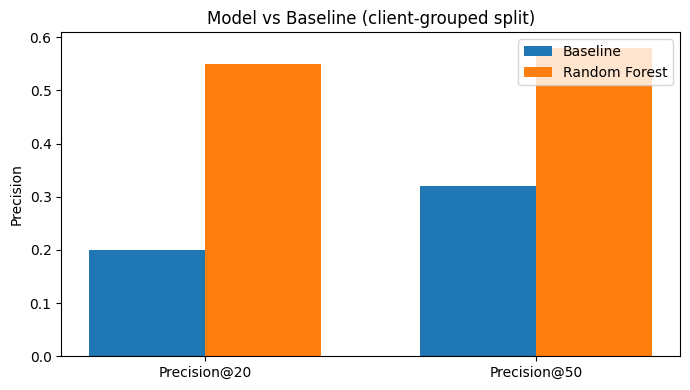

Saved figure: work/figures/model_vs_baseline.png


In [17]:
import os, json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

metrics = {
    "model": "RandomForestClassifier",
    "validation_split": "client-grouped (GroupShuffleSplit)",
    "precision_at_20": round(precision_at_k(rf_scores, y_test, 20), 3),
    "precision_at_50": round(precision_at_k(rf_scores, y_test, 50), 3),
    "baseline_precision_at_20": round(precision_at_k(baseline_test, y_test, 20), 3),
    "baseline_precision_at_50": round(precision_at_k(baseline_test, y_test, 50), 3),
    "action_distribution": ranked["final_action"].value_counts().to_dict(),
    "total_pages_scored": len(ranked),
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved metrics JSON:", metrics)

fig, ax = plt.subplots(figsize=(7, 4))
ks = [20, 50]
baseline_vals = [metrics["baseline_precision_at_20"], metrics["baseline_precision_at_50"]]
model_vals = [metrics["precision_at_20"], metrics["precision_at_50"]]
x = np.arange(len(ks))
width = 0.35
ax.bar(x - width/2, baseline_vals, width, label="Baseline")
ax.bar(x + width/2, model_vals, width, label="Random Forest")
ax.set_xticks(x)
ax.set_xticklabels([f"Precision@{k}" for k in ks])
ax.set_ylabel("Precision")
ax.set_title("Model vs Baseline (client-grouped split)")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline.png", dpi=150)
plt.show()
print("Saved figure: work/figures/model_vs_baseline.png")

## 8. Closing: Demo, social cut, and employer summary

**5-minute demo outline:**
1. (30s) The problem: content teams can't review every page — which one first?
2. (60s) Show the baseline rule and its Precision@20/50: 0.200/0.320.
3. (90s) Show the Random Forest's honest client-grouped result: 0.550/0.580.
4. (60s) Show the random-split trap: same model scored 0.950 under a naive split.
5. (60s) Show the final ranked action queue and reason codes.
6. (30s) Limitations: decision-support only, one month of data, no causal claims.

**Social post cut:**
Built a content-review prioritization model for FlyRank's ML internship — beat a transparent
baseline rule (Precision@20: 0.20) with a Random Forest (0.55) on a properly client-grouped
split. The catch: a naive random split would have shown 0.95, almost double — a reminder that
validation design matters as much as the model itself.

**3-sentence employer summary:**
I built a content-refresh prioritization model on 30,000 real (anonymized) content pages
across 32 clients, comparing a transparent baseline rule against a Random Forest under a
client-grouped validation split. The model nearly tripled the baseline's precision at top-20
(0.55 vs 0.20), while a separate check confirmed a naive random split would have overstated
results by nearly 2x. The full pipeline is documented and reproducible in my GitHub repo.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
